In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!nvdia-smi

/bin/bash: line 1: nvdia-smi: command not found


In [5]:
!wget https://bitbucket.org/ishaanjav/code-and-deploy-custom-tensorflow-lite-model/raw/a4febbfee178324b2083e322cdead7465d6fdf95/fruits.zip

--2026-07-01 12:19:02--  https://bitbucket.org/ishaanjav/code-and-deploy-custom-tensorflow-lite-model/raw/a4febbfee178324b2083e322cdead7465d6fdf95/fruits.zip
Resolving bitbucket.org (bitbucket.org)... 104.192.142.26, 104.192.142.25, 104.192.142.24, ...
Connecting to bitbucket.org (bitbucket.org)|104.192.142.26|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-07-01 12:19:03 ERROR 404: Not Found.



In [ ]:
!unzip fruits.zip


In [16]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [17]:
img_height, img_width = 32, 32
batch_size = 20

train_ds = tf.keras.utils.image_dataset_from_directory(
    "fruits/train",
    image_size = (img_height, img_width),
    batch_size = batch_size
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    "fruits/validation",
    image_size = (img_height, img_width),
    batch_size = batch_size
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    "fruits/test",
    image_size = (img_height, img_width),
    batch_size = batch_size
)

Found 460 files belonging to 3 classes.
Found 66 files belonging to 3 classes.
Found 130 files belonging to 3 classes.


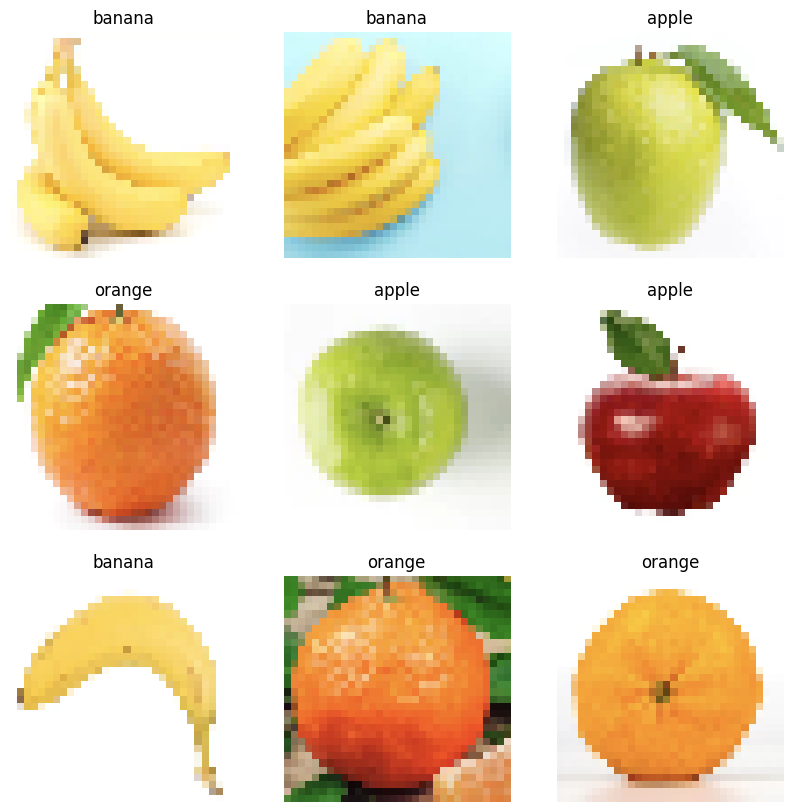

In [20]:
class_names = ["apple","banana","orange"]
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [22]:
model = tf.keras.Sequential(
    [
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='softmax'),
    tf.keras.layers.Dense(3)

    ])

In [23]:
model.compile(
    optimizer='rmsprop',
    loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'])

In [24]:
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 183ms/step - accuracy: 0.3196 - loss: 1.0973 - val_accuracy: 0.3333 - val_loss: 1.0813
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.4935 - loss: 1.0620 - val_accuracy: 0.4394 - val_loss: 1.0370
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.5826 - loss: 1.0046 - val_accuracy: 0.6212 - val_loss: 0.9686
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.6087 - loss: 0.9762 - val_accuracy: 0.6364 - val_loss: 0.9521
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.6087 - loss: 0.9624 - val_accuracy: 0.6212 - val_loss: 0.9335
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.6239 - loss: 0.9447 - val_accuracy: 0.6364 - val_loss: 0.9180
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - accuracy: 0.6435 - loss: 0.9300 - val_accuracy: 0.6212 - val_loss: 0.9079
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - accuracy: 0.6565 - loss: 0.9220 - val_accuracy: 0.5455 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step


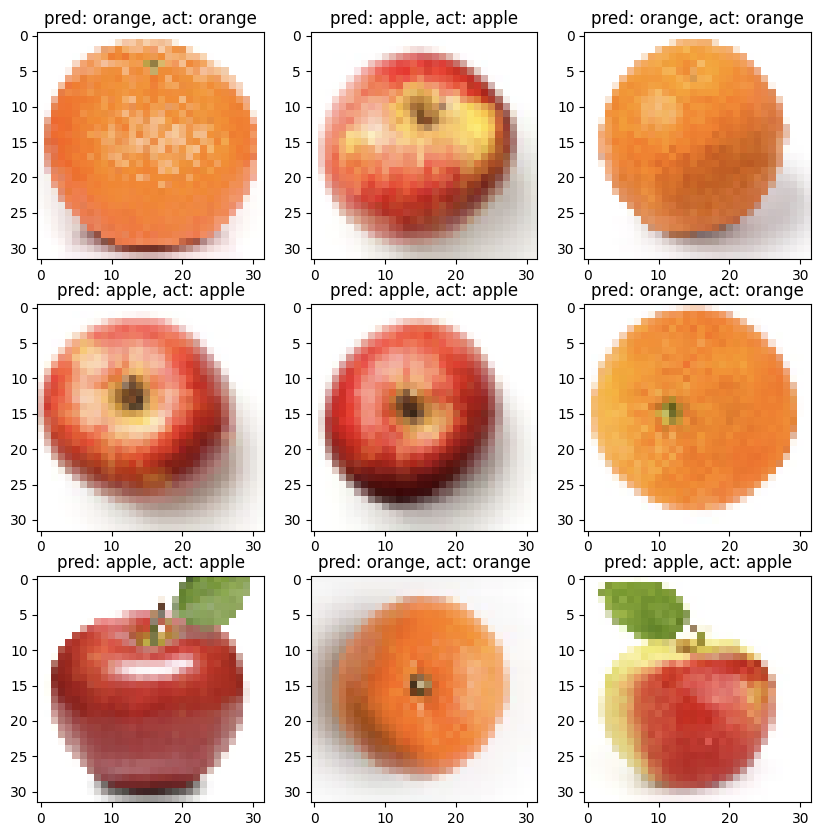

In [25]:
import numpy

plt.figure(figsize=(10, 10))

for images, labels in test_ds.take(1):
  classification = model.predict(images)

for i in range(9):
  ax = plt.subplot(3, 3, i +1)
  plt.imshow(images[i].numpy().astype("uint8"))
  index= numpy.argmax(classification[i])
  plt.title("pred: "+class_names[index]+", act: "+class_names[labels[i]])